In [1]:
import pandas as pd

In [2]:
import numpy as np

Step 1: Load and Initial Exploration


# Load the datasets

In [3]:
df_sales= pd.read_csv("/content/sample_data/zepto_sales (1).csv")

In [4]:
df_products= pd.read_csv("/content/sample_data/zepto_products (1).csv")

In [5]:
print(df_sales)
print(df_products)

        order_id           order_date  product_id  quantity       city  \
0         151992  2024-02-08 00:38:00         135         1  Bangalore   
1         109440  2024-05-31 15:49:00         102         1     Mumbai   
2         126862  2024-01-17 23:41:00         110         1     Mumbai   
3         167258  2024-11-12 09:42:00         121         3  Hyderabad   
4         159614  2024-01-02 17:50:00         112         4  Bangalore   
...          ...                  ...         ...       ...        ...   
220215    204348  2024-04-08 00:51:00         112         2     Mumbai   
220216    139692  2024-04-14 13:19:00         135         1  Bangalore   
220217    155920  2024-11-22 13:49:00         110         1  Bangalore   
220218    100568  2024-07-13 22:50:00         129         1  Bangalore   
220219    195258  2024-07-30 11:27:00         112         1      Delhi   

       delivery_status  customer_id  delivery_time_mins  total_amount  
0            Delivered        66921    

# Display basic information for sales data


In [6]:
print("\n--- Sales Data Info ---")
print(df_sales.info())
print("\n--- Sales Data Description ---")
print(df_sales.describe())
print("\n--- Sales Data Shape ---")
print(df_sales.shape)
print("\n--- Sales Data Head ---")
print(df_sales.head())
print("\n--- Sales Data Tail ---")
print(df_sales.tail())


--- Sales Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220220 entries, 0 to 220219
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   order_id            220220 non-null  int64  
 1   order_date          220220 non-null  object 
 2   product_id          220220 non-null  int64  
 3   quantity            220220 non-null  int64  
 4   city                219118 non-null  object 
 5   delivery_status     219118 non-null  object 
 6   customer_id         220220 non-null  int64  
 7   delivery_time_mins  215817 non-null  float64
 8   total_amount        220220 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 15.1+ MB
None

--- Sales Data Description ---
            order_id     product_id       quantity    customer_id  \
count  220220.000000  220220.000000  220220.000000  220220.000000   
mean   152325.652429     119.214218       1.548633   60016.100023   
std     

# Display basic information for products data


In [7]:
print("\n--- products data info---")
print(df_products.info())
print("\n--- products data description---")
print(df_products.describe())
print("\n--- product data head---")
print(df_products.head())


--- products data info---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    38 non-null     int64  
 1   product_name  38 non-null     object 
 2   category      38 non-null     object 
 3   base_price    38 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 1.3+ KB
None

--- products data description---
       product_id  base_price
count   38.000000   38.000000
mean   119.500000  211.414474
std     11.113055  139.411328
min    101.000000   23.250000
25%    110.250000  105.307500
50%    119.500000  188.005000
75%    128.750000  290.127500
max    138.000000  531.370000

--- product data head---
   product_id product_name             category  base_price
0         101        Apple  Fruits & Vegetables      103.13
1         102       Banana  Fruits & Vegetables       23.25
2         103        Onion  Fruits &

Step 2: Data Cleaning - Handling Missing Values and Duplicates

# Check for null values in sales data

In [8]:
print("\n--- Null values in sales data---")
print(df_sales.isnull().sum())


--- Null values in sales data---
order_id                 0
order_date               0
product_id               0
quantity                 0
city                  1102
delivery_status       1102
customer_id              0
delivery_time_mins    4403
total_amount             0
dtype: int64


# Handle null values in 'city' and 'delivery_status' by dropping rows


In [9]:
df_sales.dropna(subset=["city","delivery_status"],inplace=True)
print("\nNulls after dropping rows in city/delivery_status:")
print(df_sales[["city","delivery_status"]].isnull().sum())


Nulls after dropping rows in city/delivery_status:
city               0
delivery_status    0
dtype: int64


# Handle null values in 'delivery_time_mins' by filling with the mean


In [10]:
mean_delivery_time=df_sales["delivery_time_mins"].mean()
df_sales["delivery_time_mins"].fillna(mean_delivery_time,inplace=True)
print("\nNulls after filling mean in delivery_time_mins:")
print(df_sales["delivery_time_mins"].isnull().sum())


Nulls after filling mean in delivery_time_mins:
0


/tmp/ipykernel_6062/4249494788.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_sales["delivery_time_mins"].fillna(mean_delivery_time,inplace=True)


# Check for duplicate records


In [11]:
print("\n--- Duplicate Records in Sales Data ---")
print(f"Number of duplicates row: {df_sales.duplicated().sum()}")


--- Duplicate Records in Sales Data ---
Number of duplicates row: 216


# Remove duplicate records


In [12]:
df_sales.drop_duplicates(inplace=True)
print(f"Number of rows after removing duplicates: {df_sales.shape[0]}")

Number of rows after removing duplicates: 217806


# Convert 'order_date' to datetime objects


In [13]:
df_sales["order_date"]=pd.to_datetime(df_sales["order_date"])

Step 3:Data Analysis - Aggregations and Grouping

In [14]:
min_amount=df_sales["total_amount"].min()
max_amount=df_sales["total_amount"].max()
avg_amount=df_sales["total_amount"].mean()
print(f"\n--- min total amount:{min_amount:.2f}")
print(f"\n--- max total amount:{max_amount:.3f}")
print(f"\n---avg total amount:{avg_amount:.2f}")


--- min total amount:23.25

--- max total amount:2656.850

---avg total amount:302.32


# Top 5 products by total sales amount

In [15]:
top_products=df_sales.groupby("product_id")["total_amount"].sum().nlargest(5)
print("\n--- top 5 products by sales")
print(top_products)


--- top 5 products by sales
product_id
134    11658720.91
112     7908234.46
135     6171994.29
129     4796676.99
131     4716913.11
Name: total_amount, dtype: float64


# Merge with product details to get product names

In [16]:
top_products_details=top_products.reset_index().merge(df_products,on="product_id")
print("--- Top 5 Products by Sales Amount (with names) ---")
print(top_products_details[["product_name","category","total_amount"]])

--- Top 5 Products by Sales Amount (with names) ---
    product_name              category  total_amount
0       Handwash         Personal Care   11658720.91
1    Paneer 200g          Dairy & Eggs    7908234.46
2     Toothpaste         Personal Care    6171994.29
3  Detergent 1kg  Household Essentials    4796676.99
4   Toilet Paper  Household Essentials    4716913.11


# Total sales by city


In [17]:
sales_by_city =df_sales.groupby("city")["total_amount"].sum().sort_values(ascending=False)
print("\n---total sales by city---")
print(sales_by_city)


---total sales by city---
city
Mumbai       23063075.50
Bangalore    16385777.49
Delhi         9937151.01
Hyderabad     5305224.53
Pune          4559465.47
Kolkata       2671042.99
Chennai       2563667.49
Ahmedabad     1362556.30
Name: total_amount, dtype: float64


# Average delivery time by city


In [18]:
avg_delivery_time_city=df_sales.groupby("city")["delivery_time_mins"].mean().sort_values()
print("\n--- Average Delivery Time by City (minutes) ---")
print(avg_delivery_time_city)


--- Average Delivery Time by City (minutes) ---
city
Hyderabad    25.914055
Mumbai       25.979052
Bangalore    26.015561
Delhi        26.037475
Pune         26.040857
Chennai      26.059007
Kolkata      26.089218
Ahmedabad    26.170095
Name: delivery_time_mins, dtype: float64


# Sales trend over time (e.g., monthly sales)

In [19]:
df_sales["month"]=df_sales["order_date"].dt.to_period("M")
monthly_sales=df_sales.groupby("month")["total_amount"].sum()
print("\n--- Monthly Sales Trend ---")
print(monthly_sales)



--- Monthly Sales Trend ---
month
2024-01    5593297.49
2024-02    5286182.10
2024-03    5569350.76
2024-04    5375568.99
2024-05    5574801.37
2024-06    5380702.74
2024-07    5523114.55
2024-08    5468629.63
2024-09    5386353.65
2024-10    5547622.90
2024-11    5451878.37
2024-12    5690458.23
Freq: M, Name: total_amount, dtype: float64


# Sales by product category

In [20]:
sales_by_category=df_sales.merge(df_products,on="product_id")
sales_by_category= sales_by_category.groupby("category")["total_amount"].sum().sort_values(ascending=False)
print("\n--- Total Sales by Product Category ---")
print(sales_by_category)



--- Total Sales by Product Category ---
category
Personal Care           23399215.51
Dairy & Eggs            12344371.12
Household Essentials    11975638.84
Munchies                 8083367.83
Beverages                6598799.13
Fruits & Vegetables      3446568.35
Name: total_amount, dtype: float64


 Step 4: Data Visualization with Matplotlib & Seaborn


Create various charts to visualize the insights gained from your analysis. Ensure your
plots are clearly labeled and easy to understand


In [47]:
import matplotlib.pyplot as plt

In [48]:

import seaborn as sns

In [23]:
sns.set_style("whitegrid")

# Create a 3x3 subplot grid

Text(0.5, 1.03, 'Zepto Sales Data Visualizations')

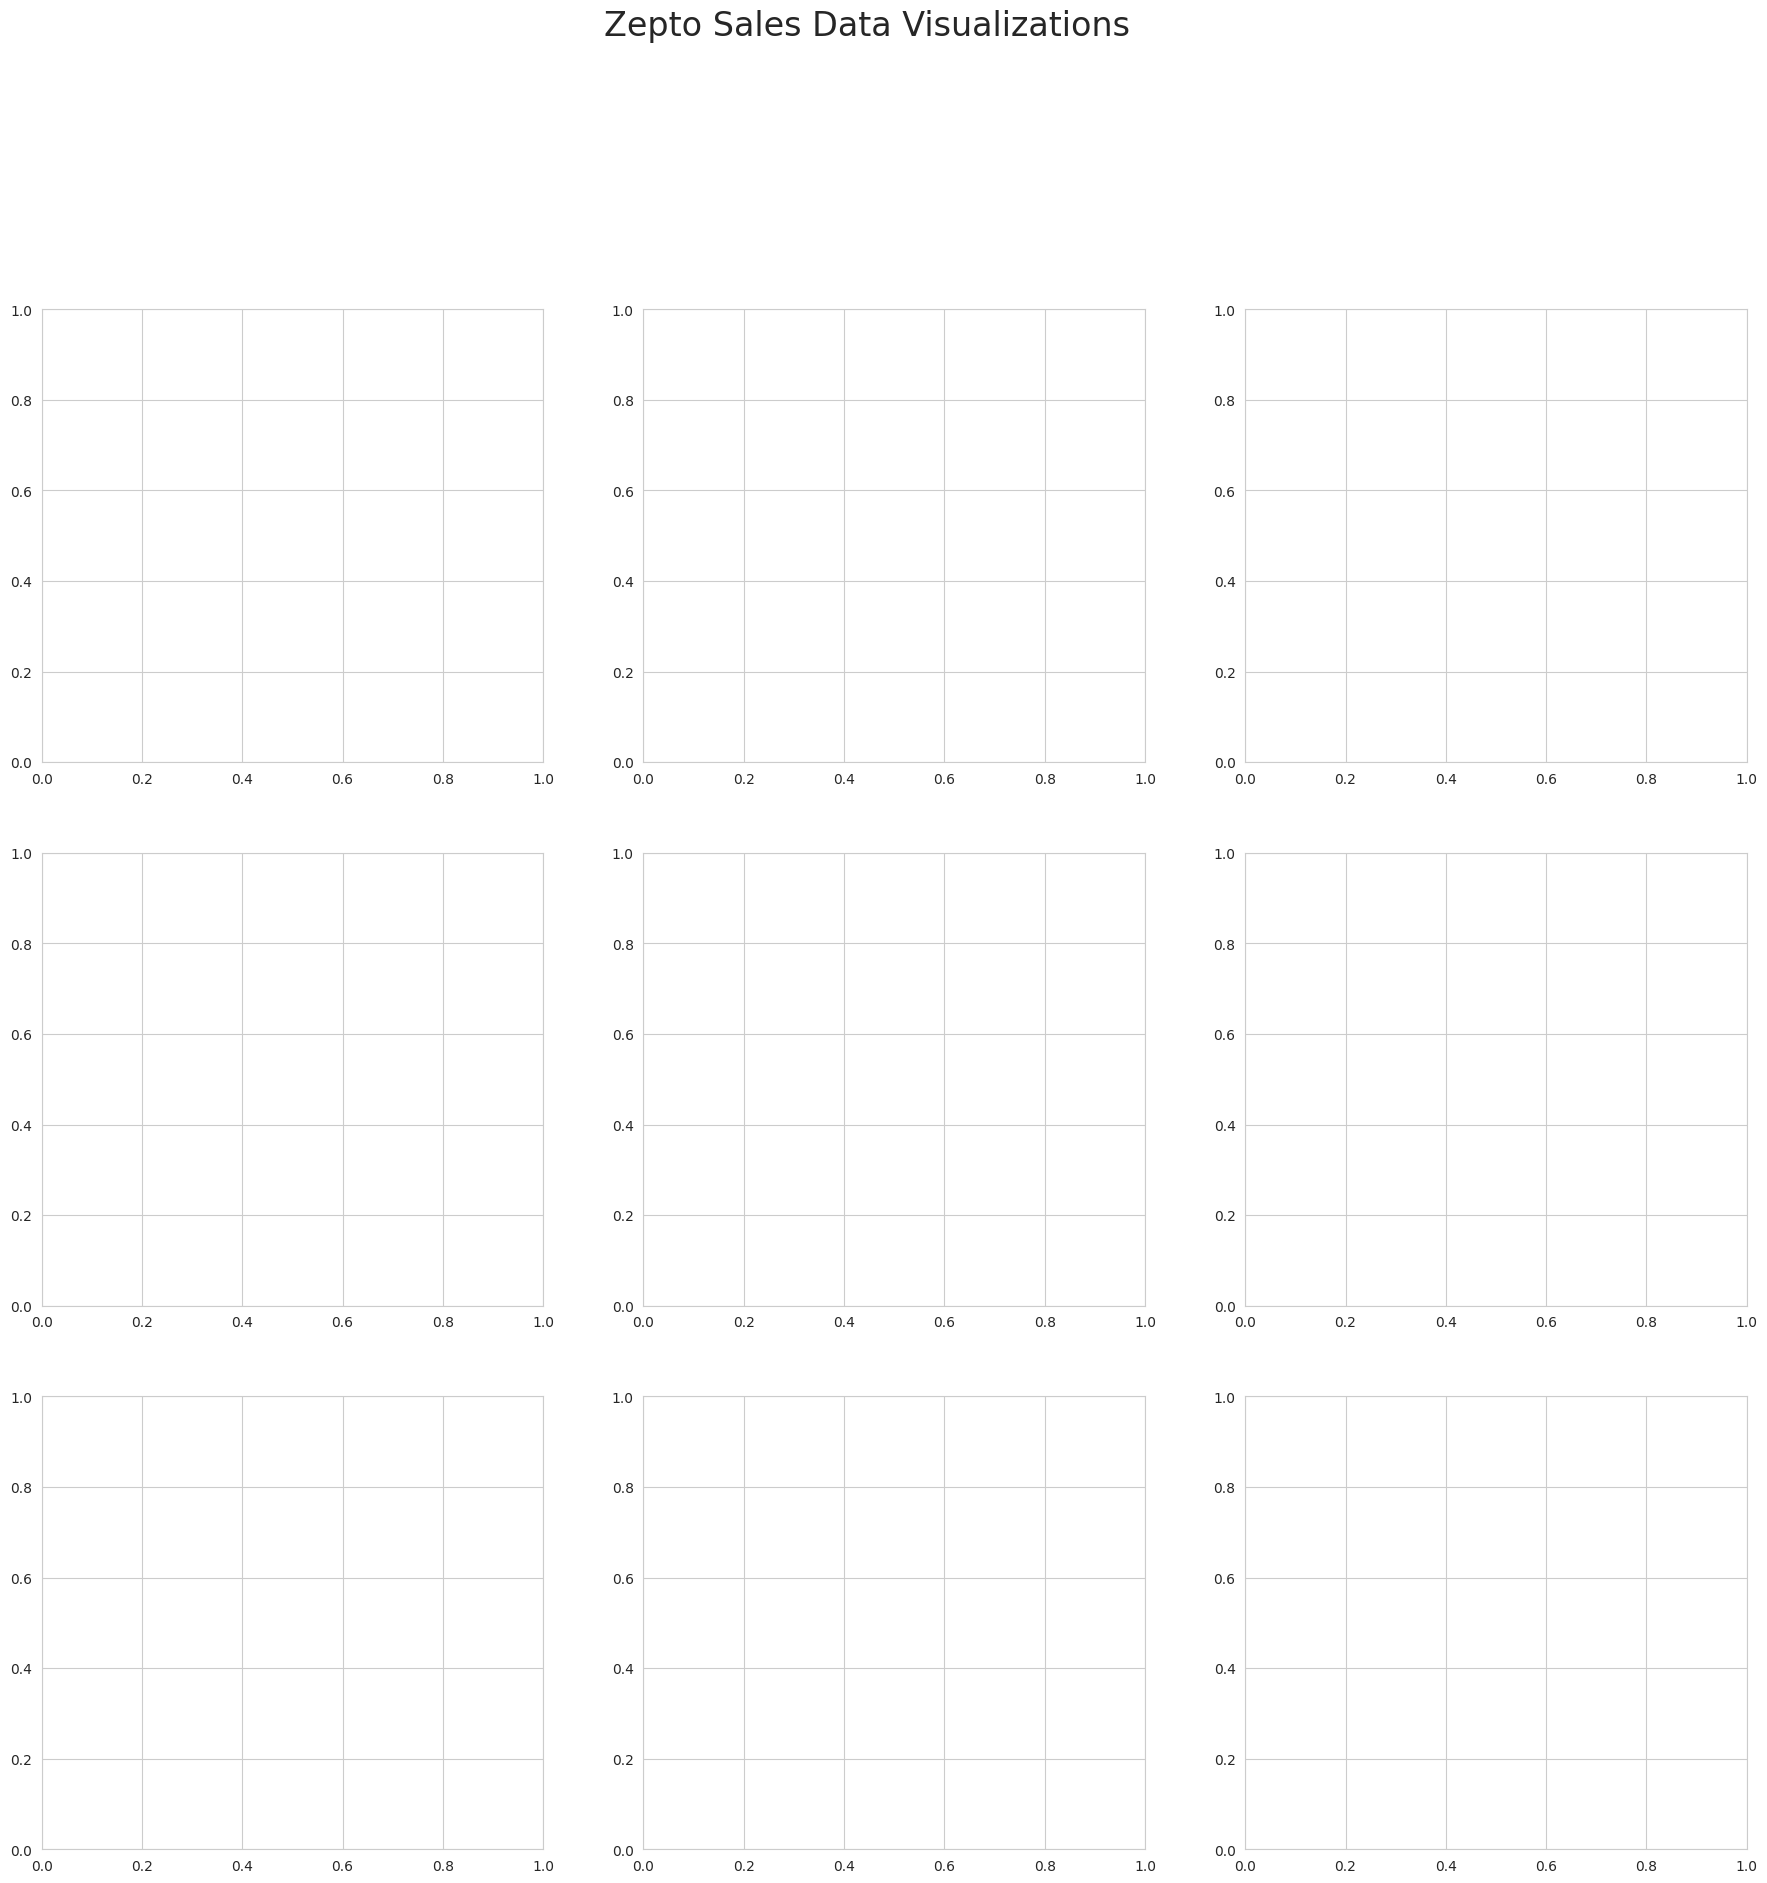

In [44]:
fig, axes = plt.subplots(3, 3, figsize=(22, 20))
fig.suptitle("Zepto Sales Data Visualizations", fontsize=24, y=1.03)

# Plot 1: Monthly Sales Trend (Line Chart)

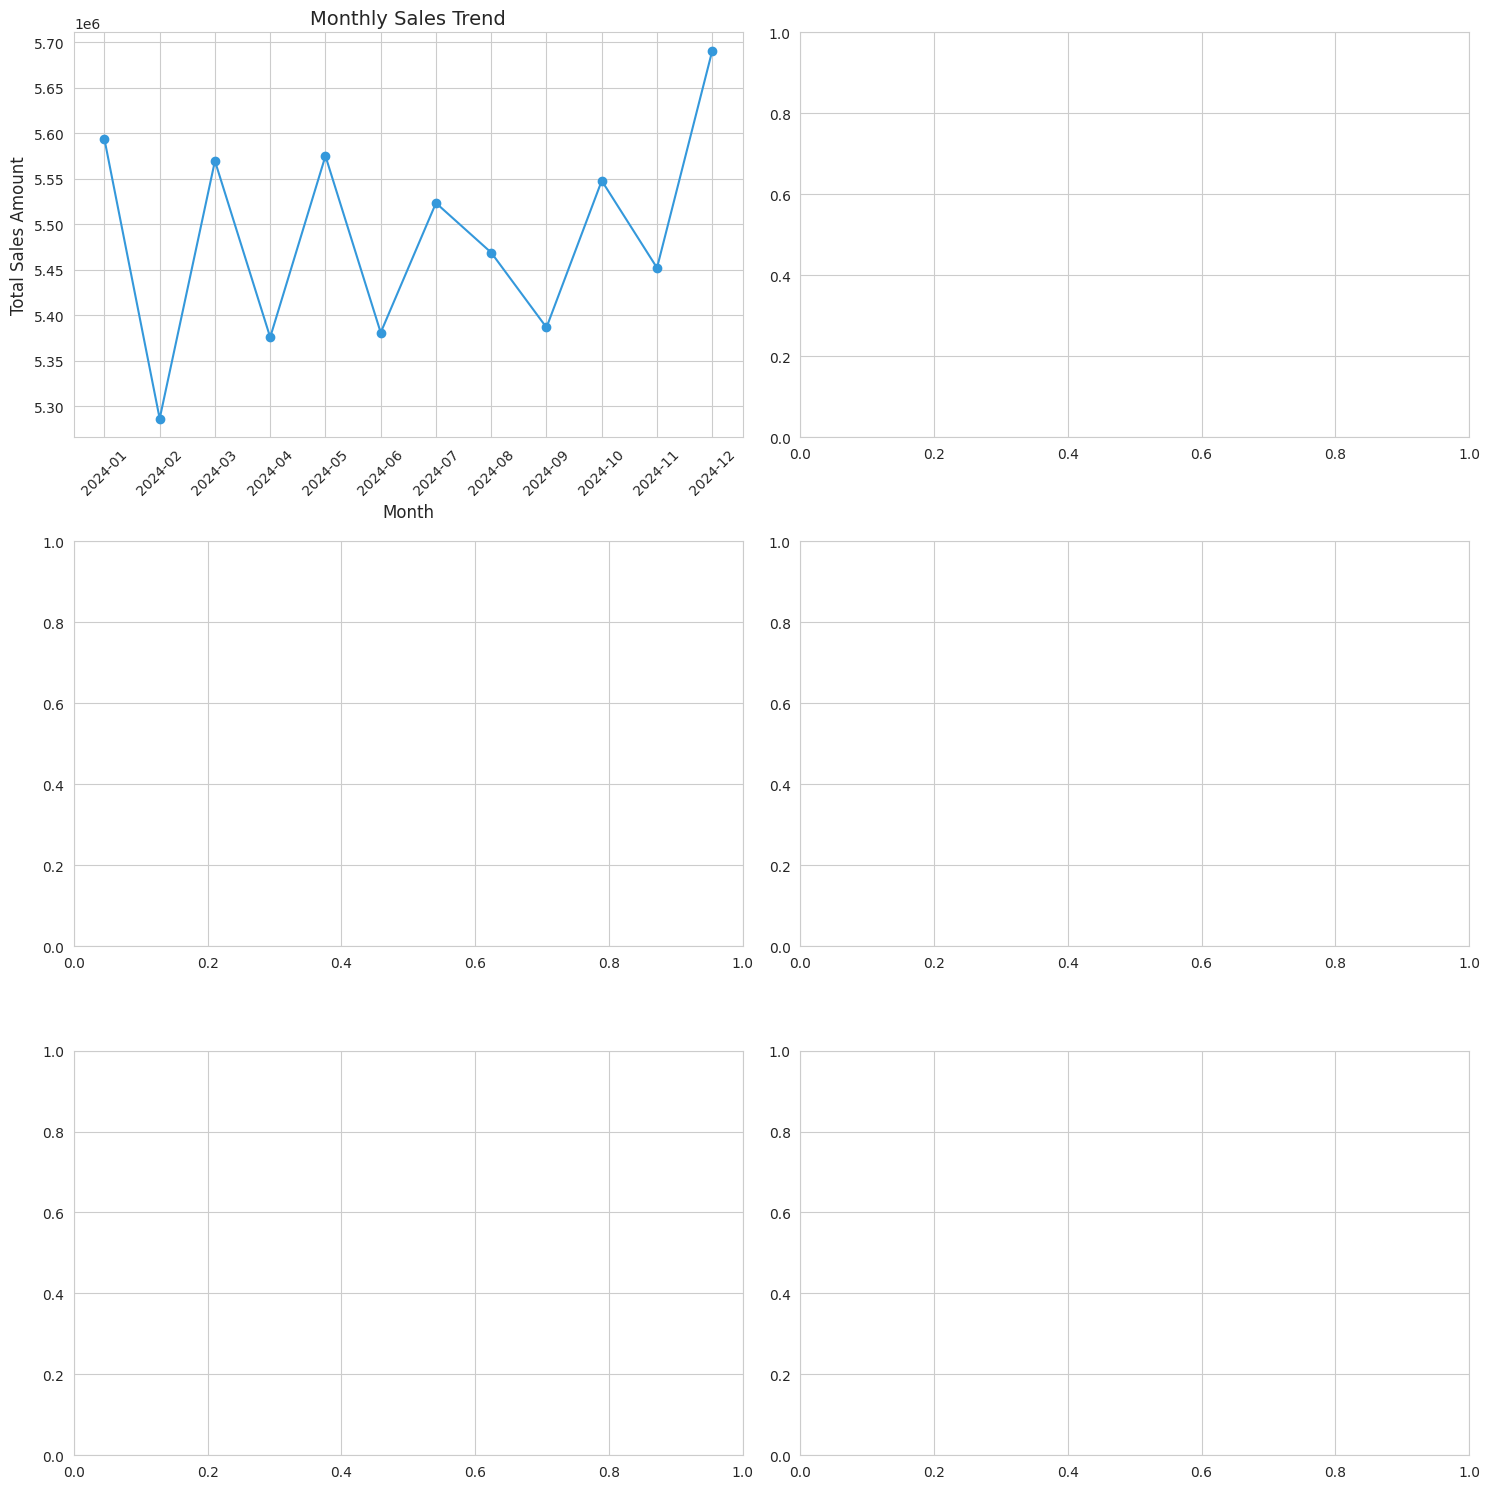

In [49]:


fig, axes = plt.subplots(3, 2, figsize=(15, 15))

# Plot 1
axes[0, 0].plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker='o',
    color='#3498DB'
)

axes[0, 0].set_title('Monthly Sales Trend', fontsize=14)
axes[0, 0].set_xlabel('Month', fontsize=12)
axes[0, 0].set_ylabel('Total Sales Amount', fontsize=12)
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True)

plt.tight_layout()
plt.show()

# Plot 2: Total Sales by City (Bar Chart)

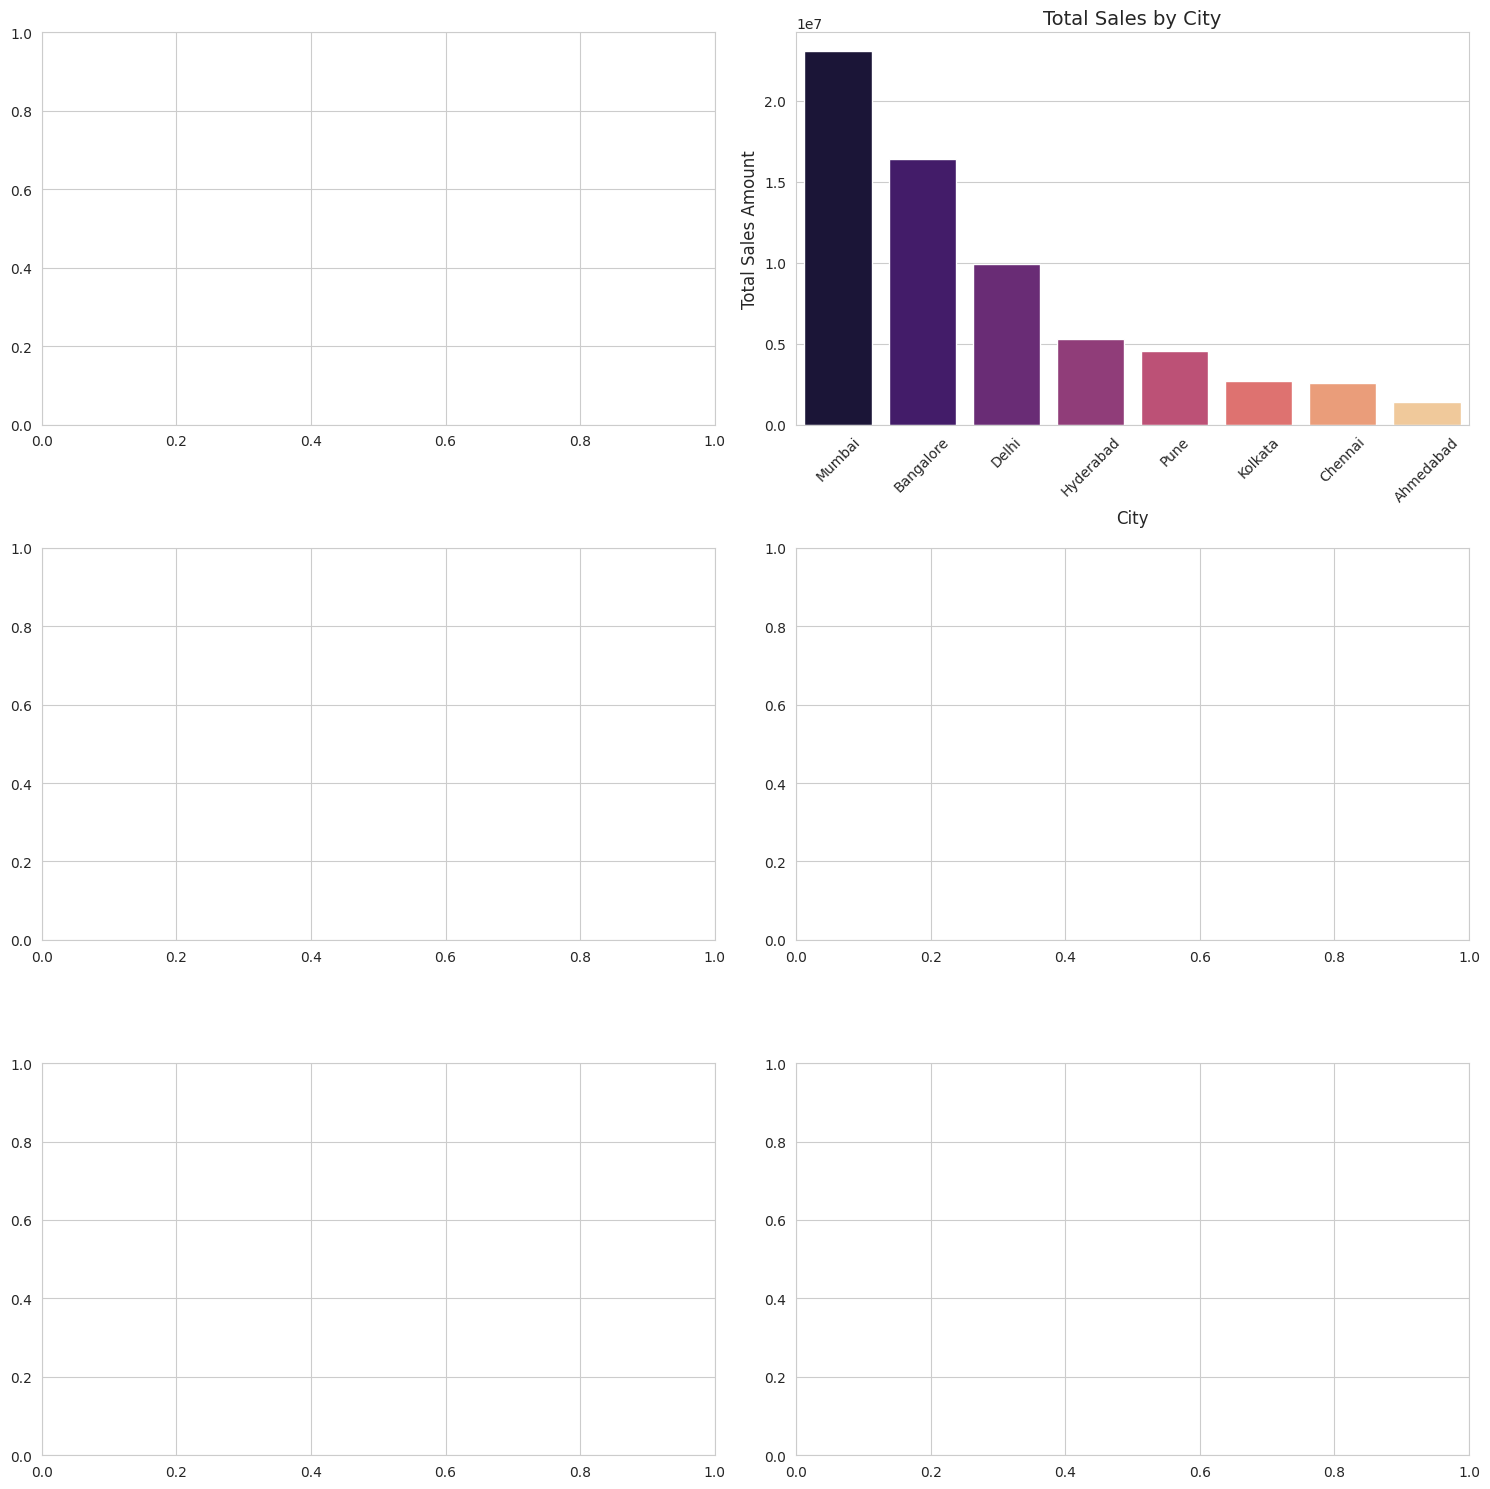

In [53]:

fig, axes = plt.subplots(3, 2, figsize=(15,15))

sns.barplot(
    x=sales_by_city.index,
    y=sales_by_city.values,
    hue=sales_by_city.index,
    palette='magma',
    legend=False,
    ax=axes[0,1]
)

axes[0,1].set_title('Total Sales by City', fontsize=14)
axes[0,1].set_xlabel('City', fontsize=12)
axes[0,1].set_ylabel('Total Sales Amount', fontsize=12)
axes[0,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Plot 3: Sales by Product Category (Pie Chart)

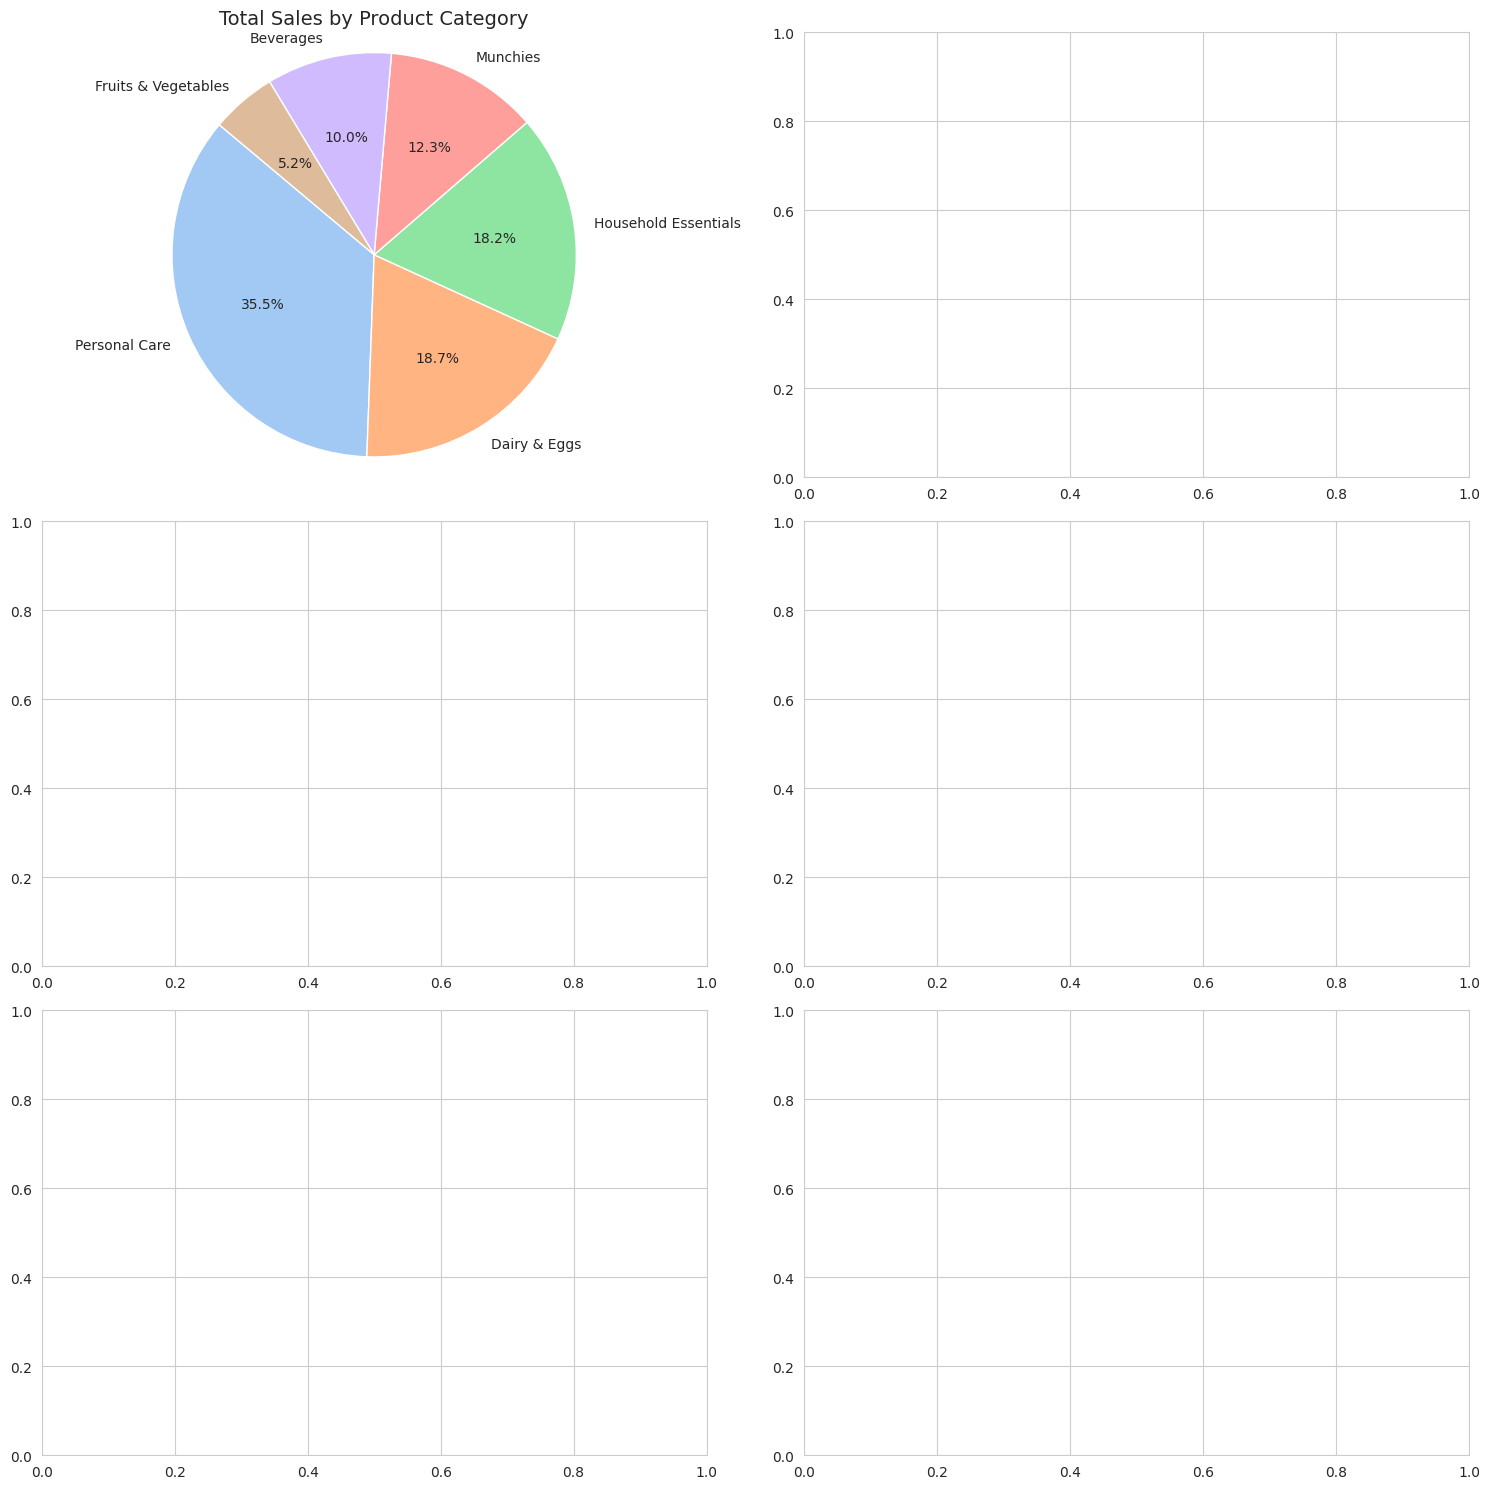

In [54]:
fig, axes = plt.subplots(3, 2, figsize=(15,15))

axes[0,0].pie(
    sales_by_category,
    labels=sales_by_category.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('pastel')
)

axes[0,0].set_title('Total Sales by Product Category', fontsize=14)
axes[0,0].axis('equal')

plt.tight_layout()
plt.show()

# Plot 4: Distribution of Delivery Times (Histogram)

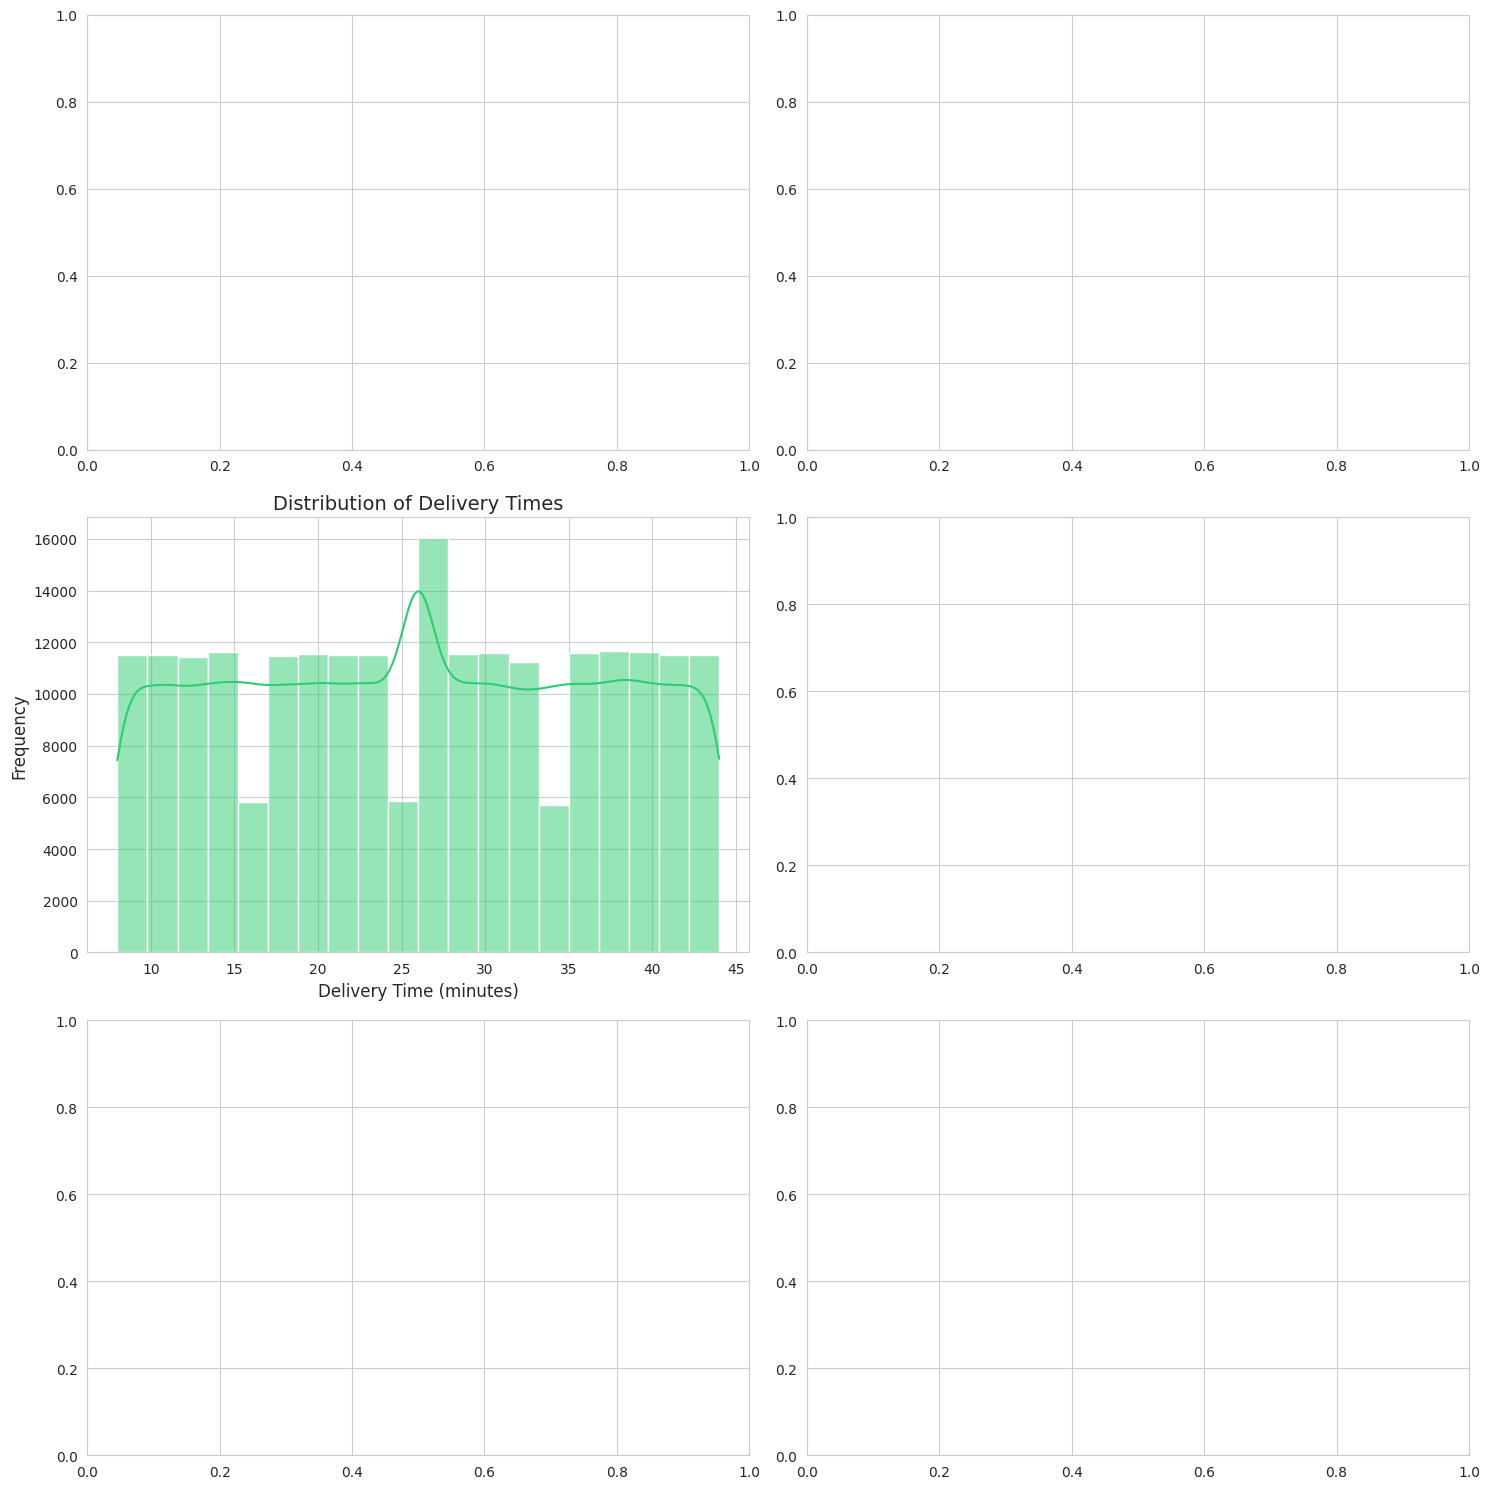

In [57]:

# Create subplot figure
fig, axes = plt.subplots(3, 2, figsize=(15,15))

# Histogram
sns.histplot(
    df_sales['delivery_time_mins'],
    bins=20,
    kde=True,
    color='#2ECC71',
    ax=axes[1,0]
)

axes[1,0].set_title('Distribution of Delivery Times', fontsize=14)
axes[1,0].set_xlabel('Delivery Time (minutes)', fontsize=12)
axes[1,0].set_ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()

# Plot 5: Quantity vs. Total Amount (Scatter Plot)

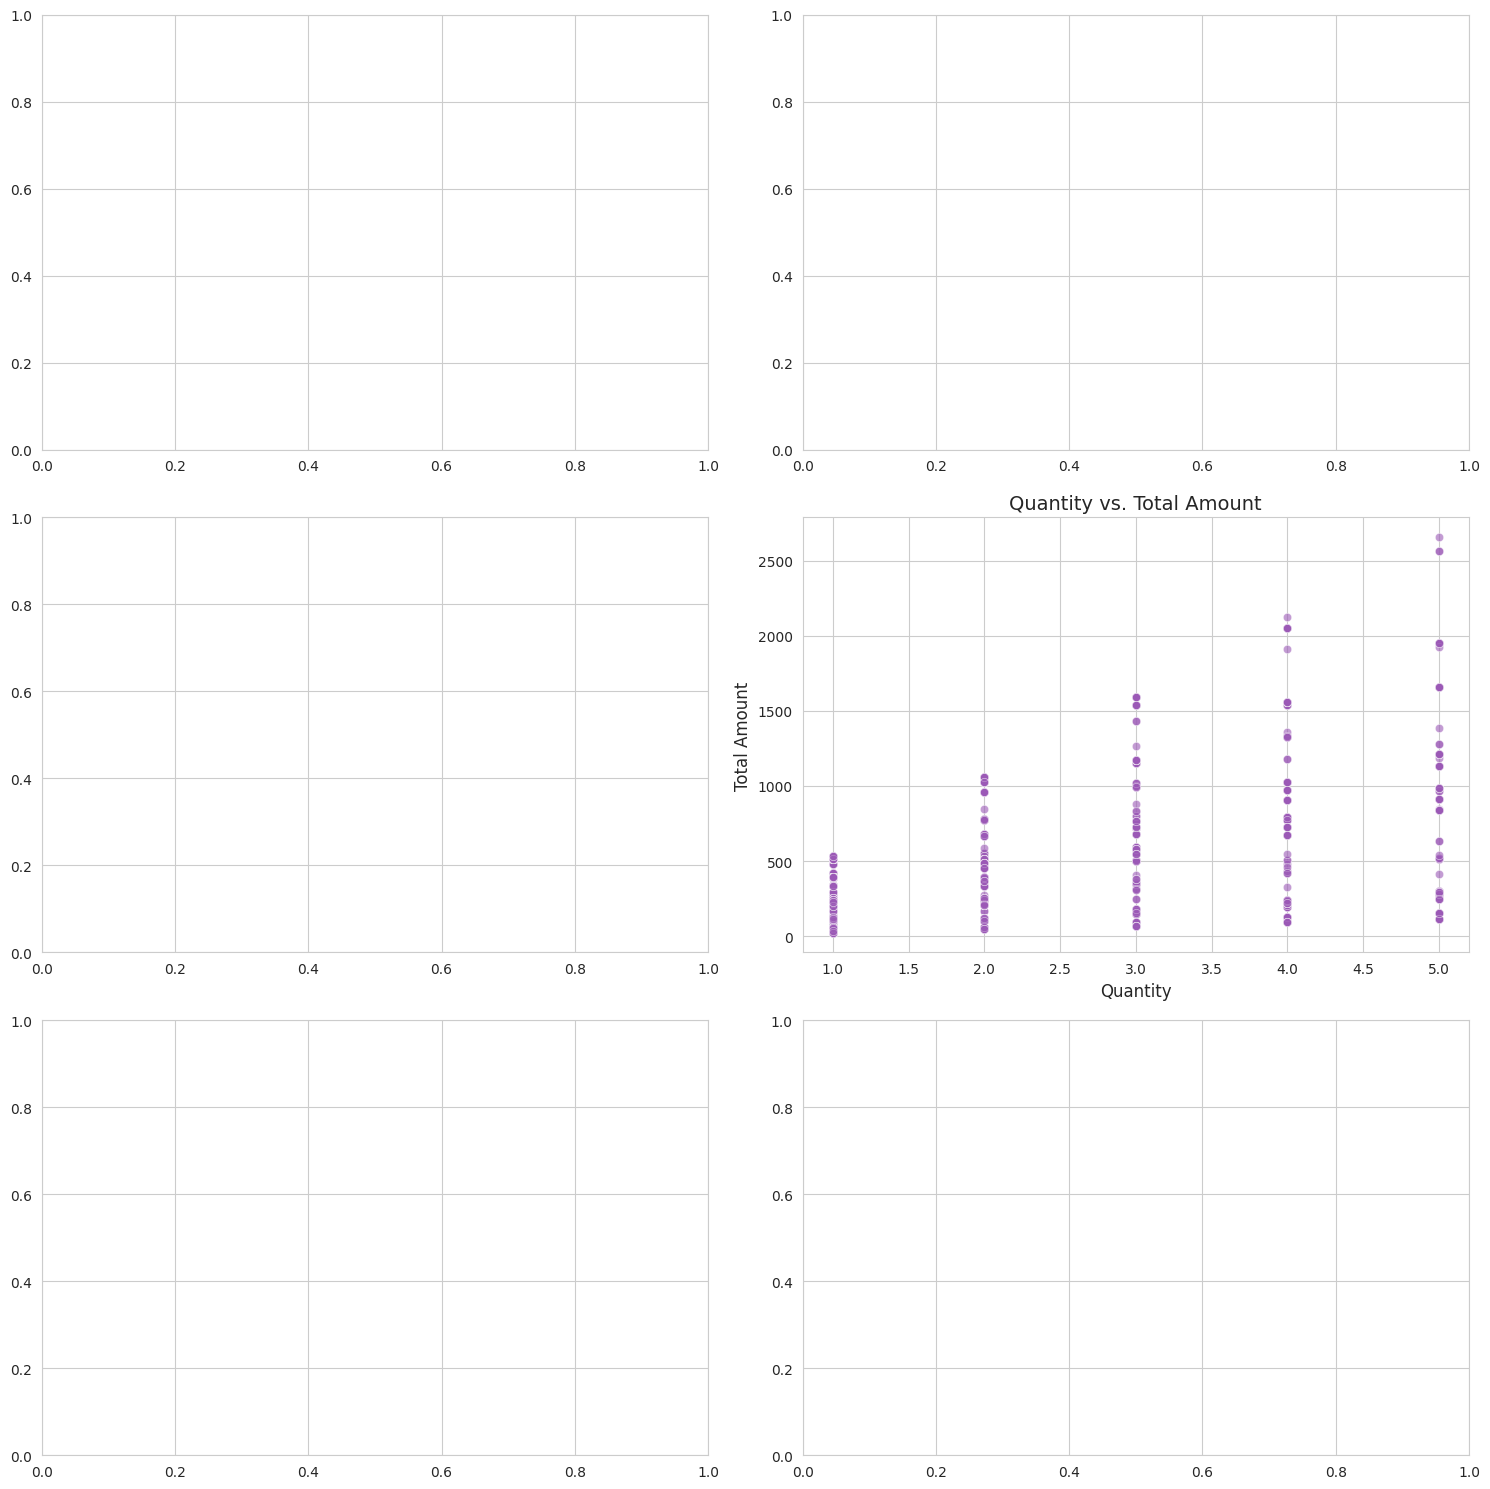

In [58]:
fig, axes = plt.subplots(3, 2, figsize=(15,15))

sns.scatterplot(
    x='quantity',
    y='total_amount',
    data=df_sales.sample(n=5000),
    alpha=0.6,
    color='#9B59B6',
    ax=axes[1,1]
)

axes[1,1].set_title('Quantity vs. Total Amount', fontsize=14)
axes[1,1].set_xlabel('Quantity', fontsize=12)
axes[1,1].set_ylabel('Total Amount', fontsize=12)

plt.tight_layout()
plt.show()

# Plot 6: Delivery Status Distribution (Count Plot)

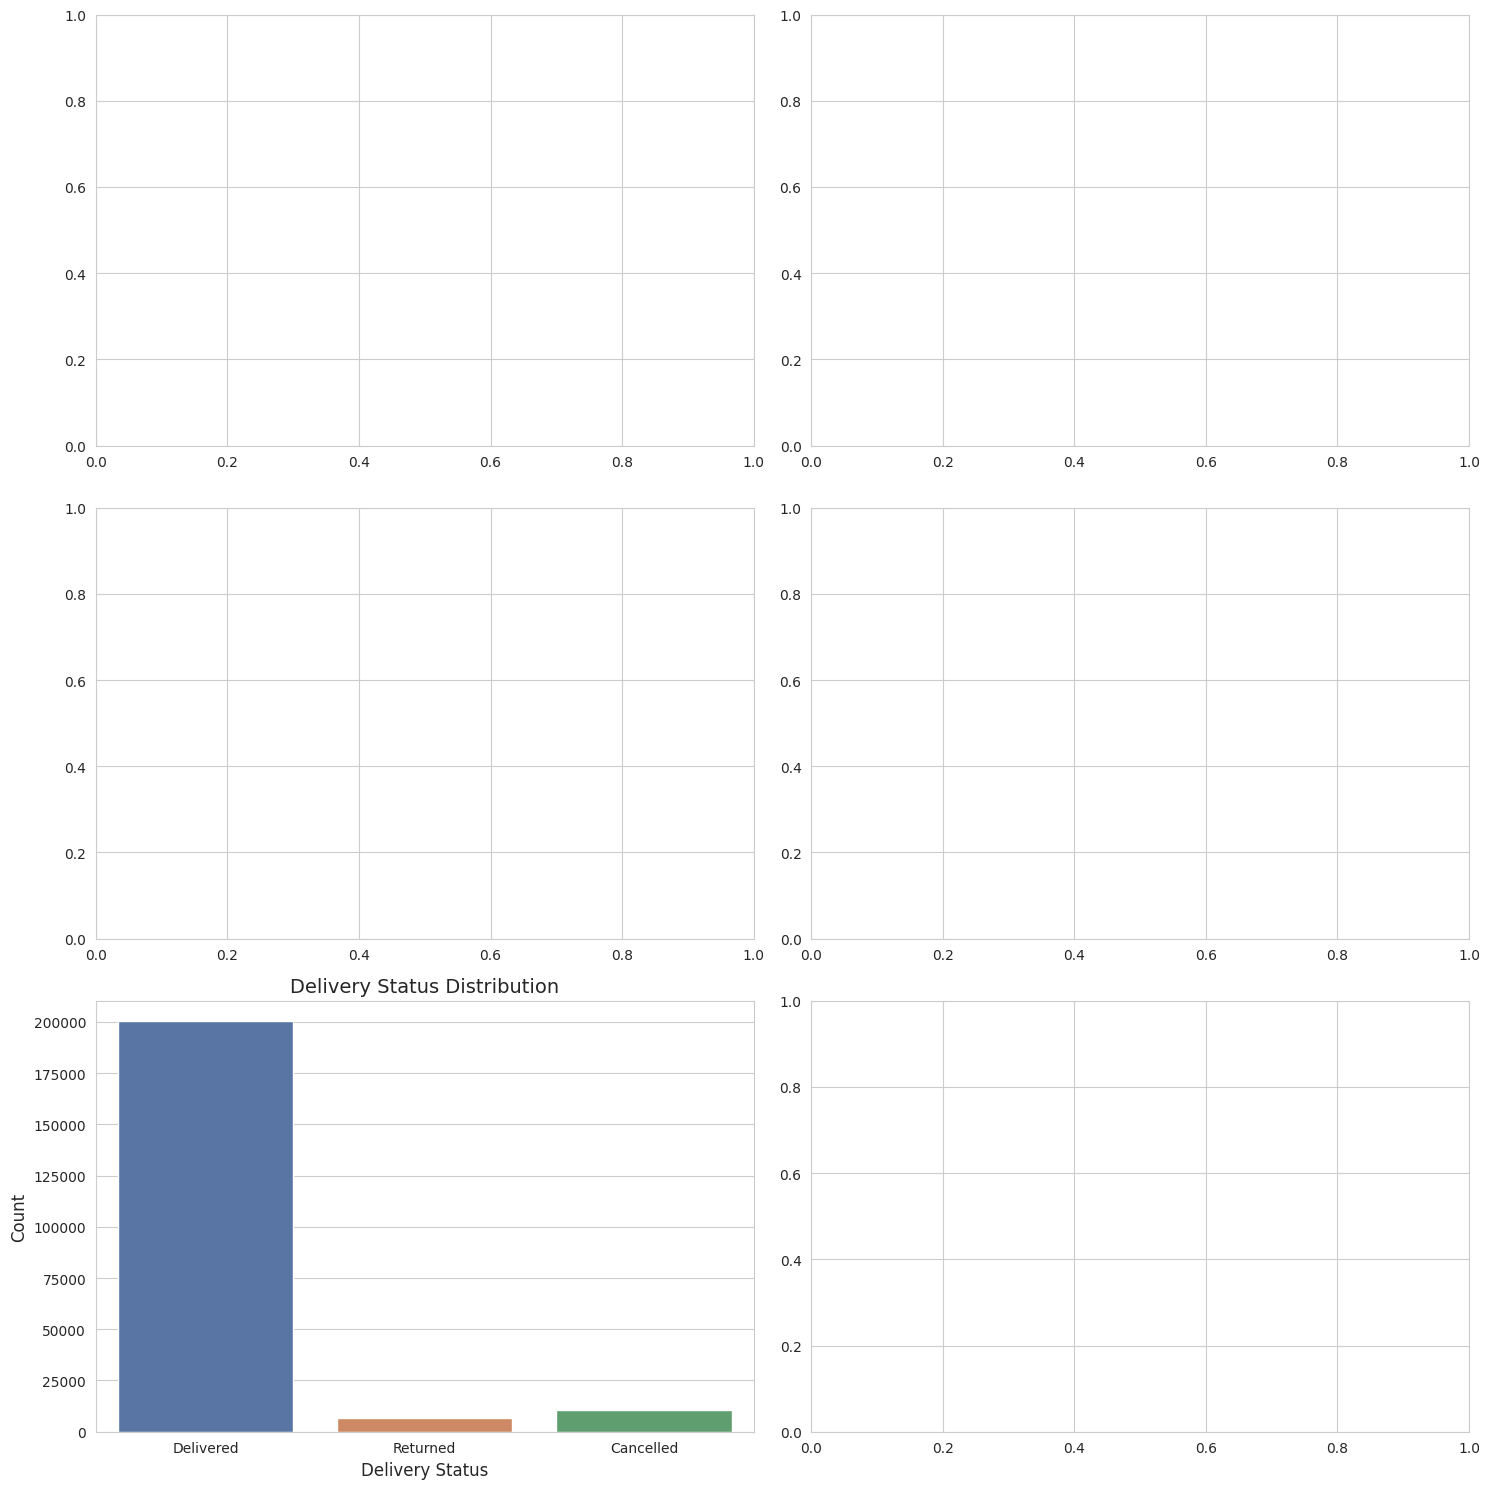

In [60]:


# Create figure with 6 subplots
fig, axes = plt.subplots(3, 2, figsize=(15,15))

# Plot 6
sns.countplot(
    x='delivery_status',
    data=df_sales,
    hue='delivery_status',
    palette='deep',
    legend=False,
    ax=axes[2,0]
)

axes[2,0].set_title('Delivery Status Distribution', fontsize=14)
axes[2,0].set_xlabel('Delivery Status', fontsize=12)
axes[2,0].set_ylabel('Count', fontsize=12)

plt.tight_layout()
plt.show()


# Plot 7: Delivery Time by City (Box Plot)

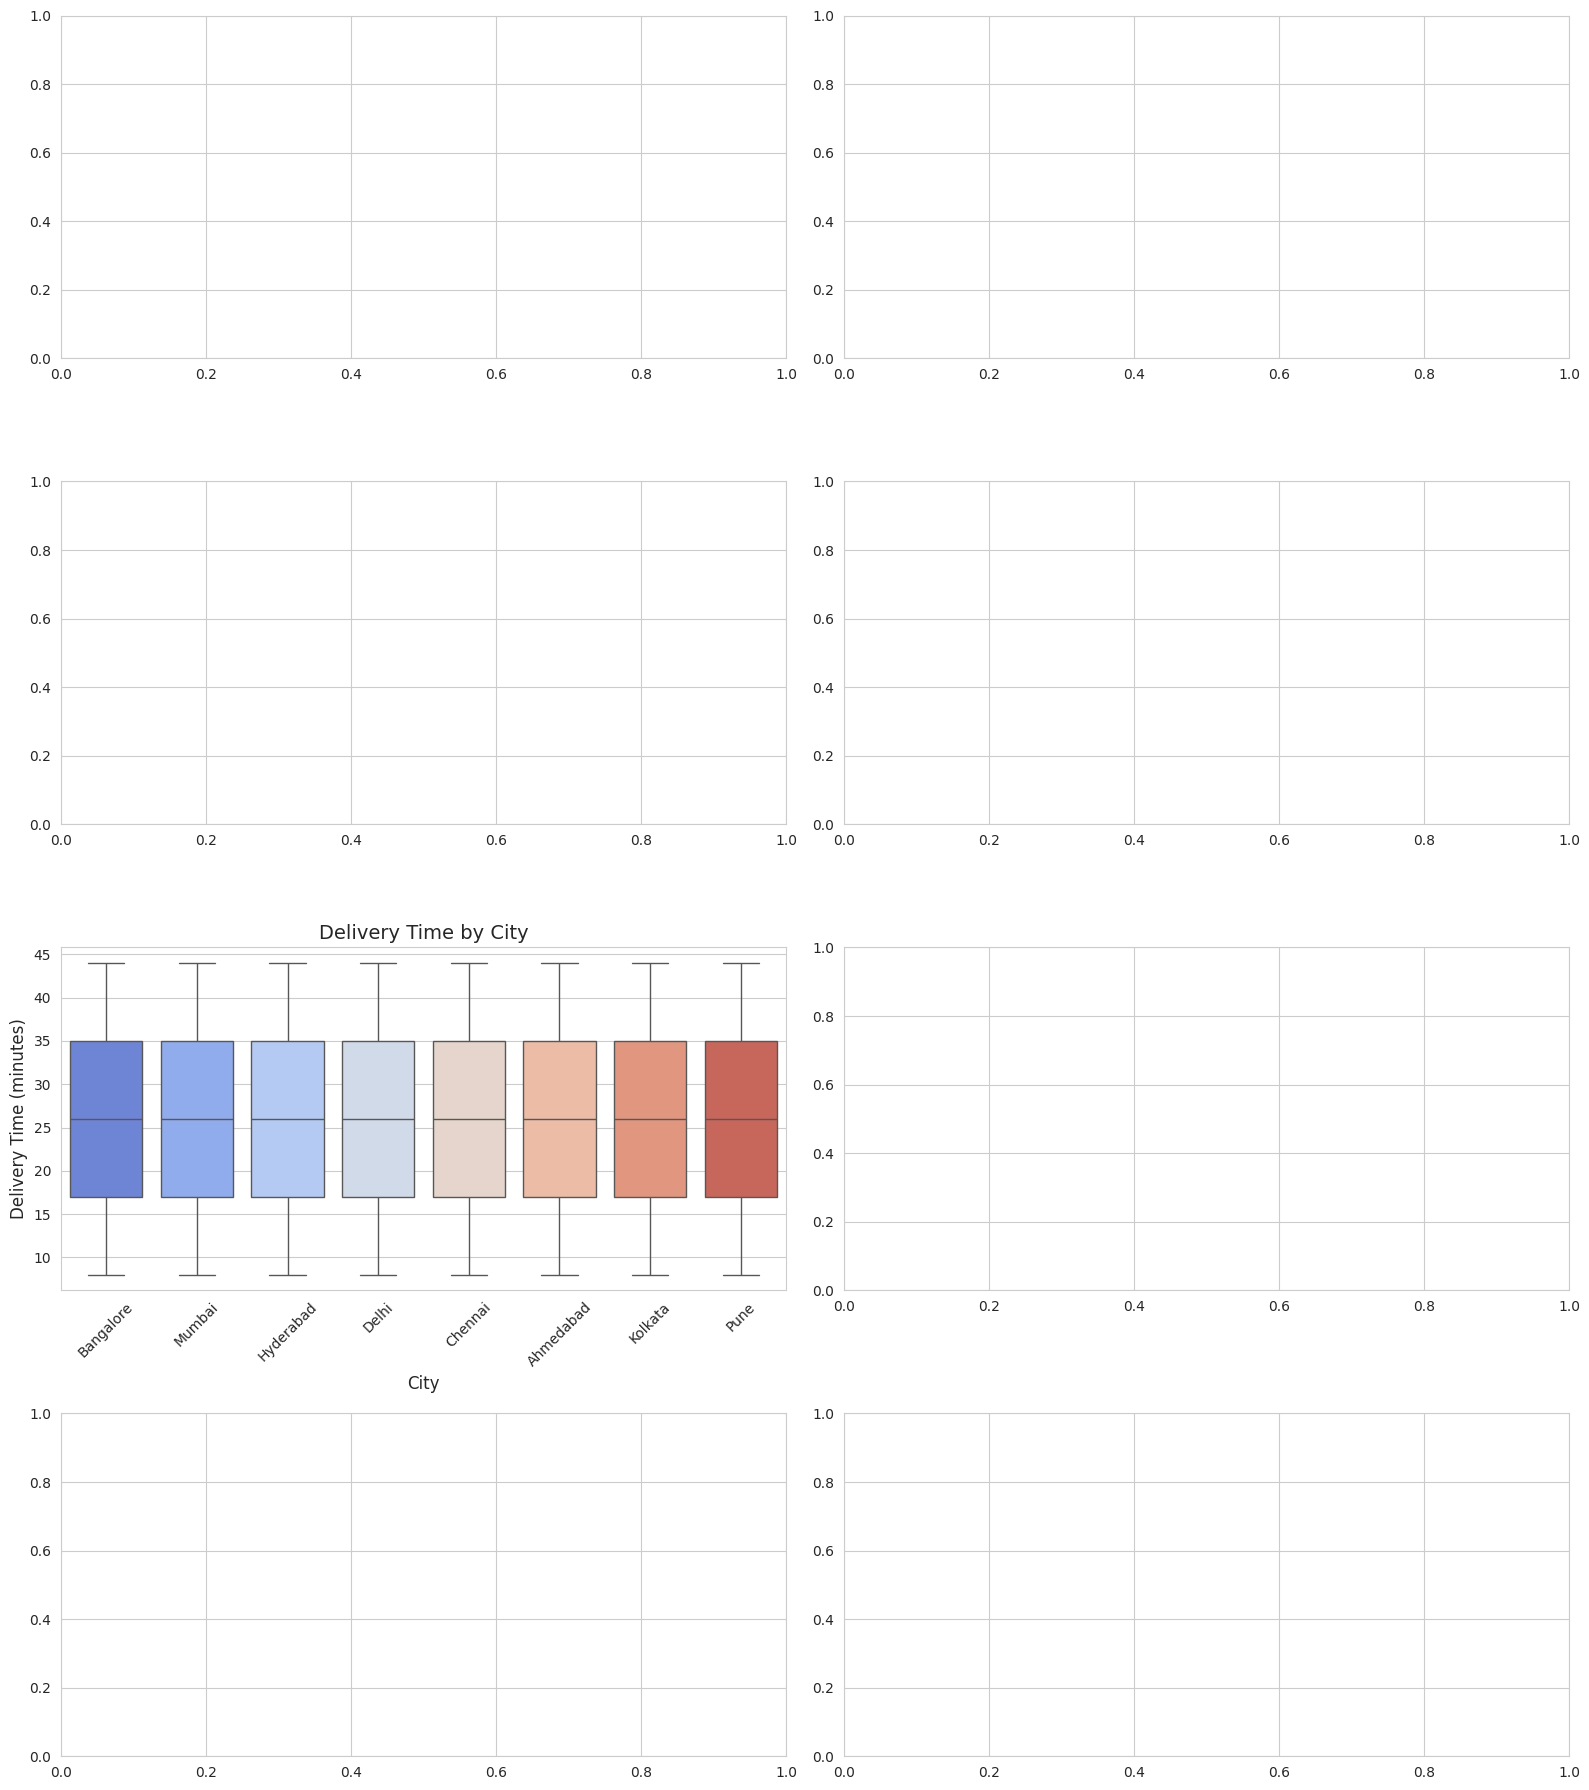

In [61]:
fig, axes = plt.subplots(4, 2, figsize=(16,18))

sns.boxplot(
    x='city',
    y='delivery_time_mins',
    data=df_sales,
    hue='city',
    palette='coolwarm',
    legend=False,
    ax=axes[2,0]
)

axes[2,0].set_title('Delivery Time by City', fontsize=14)
axes[2,0].set_xlabel('City', fontsize=12)
axes[2,0].set_ylabel('Delivery Time (minutes)', fontsize=12)
axes[2,0].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Plot 8: Top 5 Products by Quantity Sold (Bar Plot)

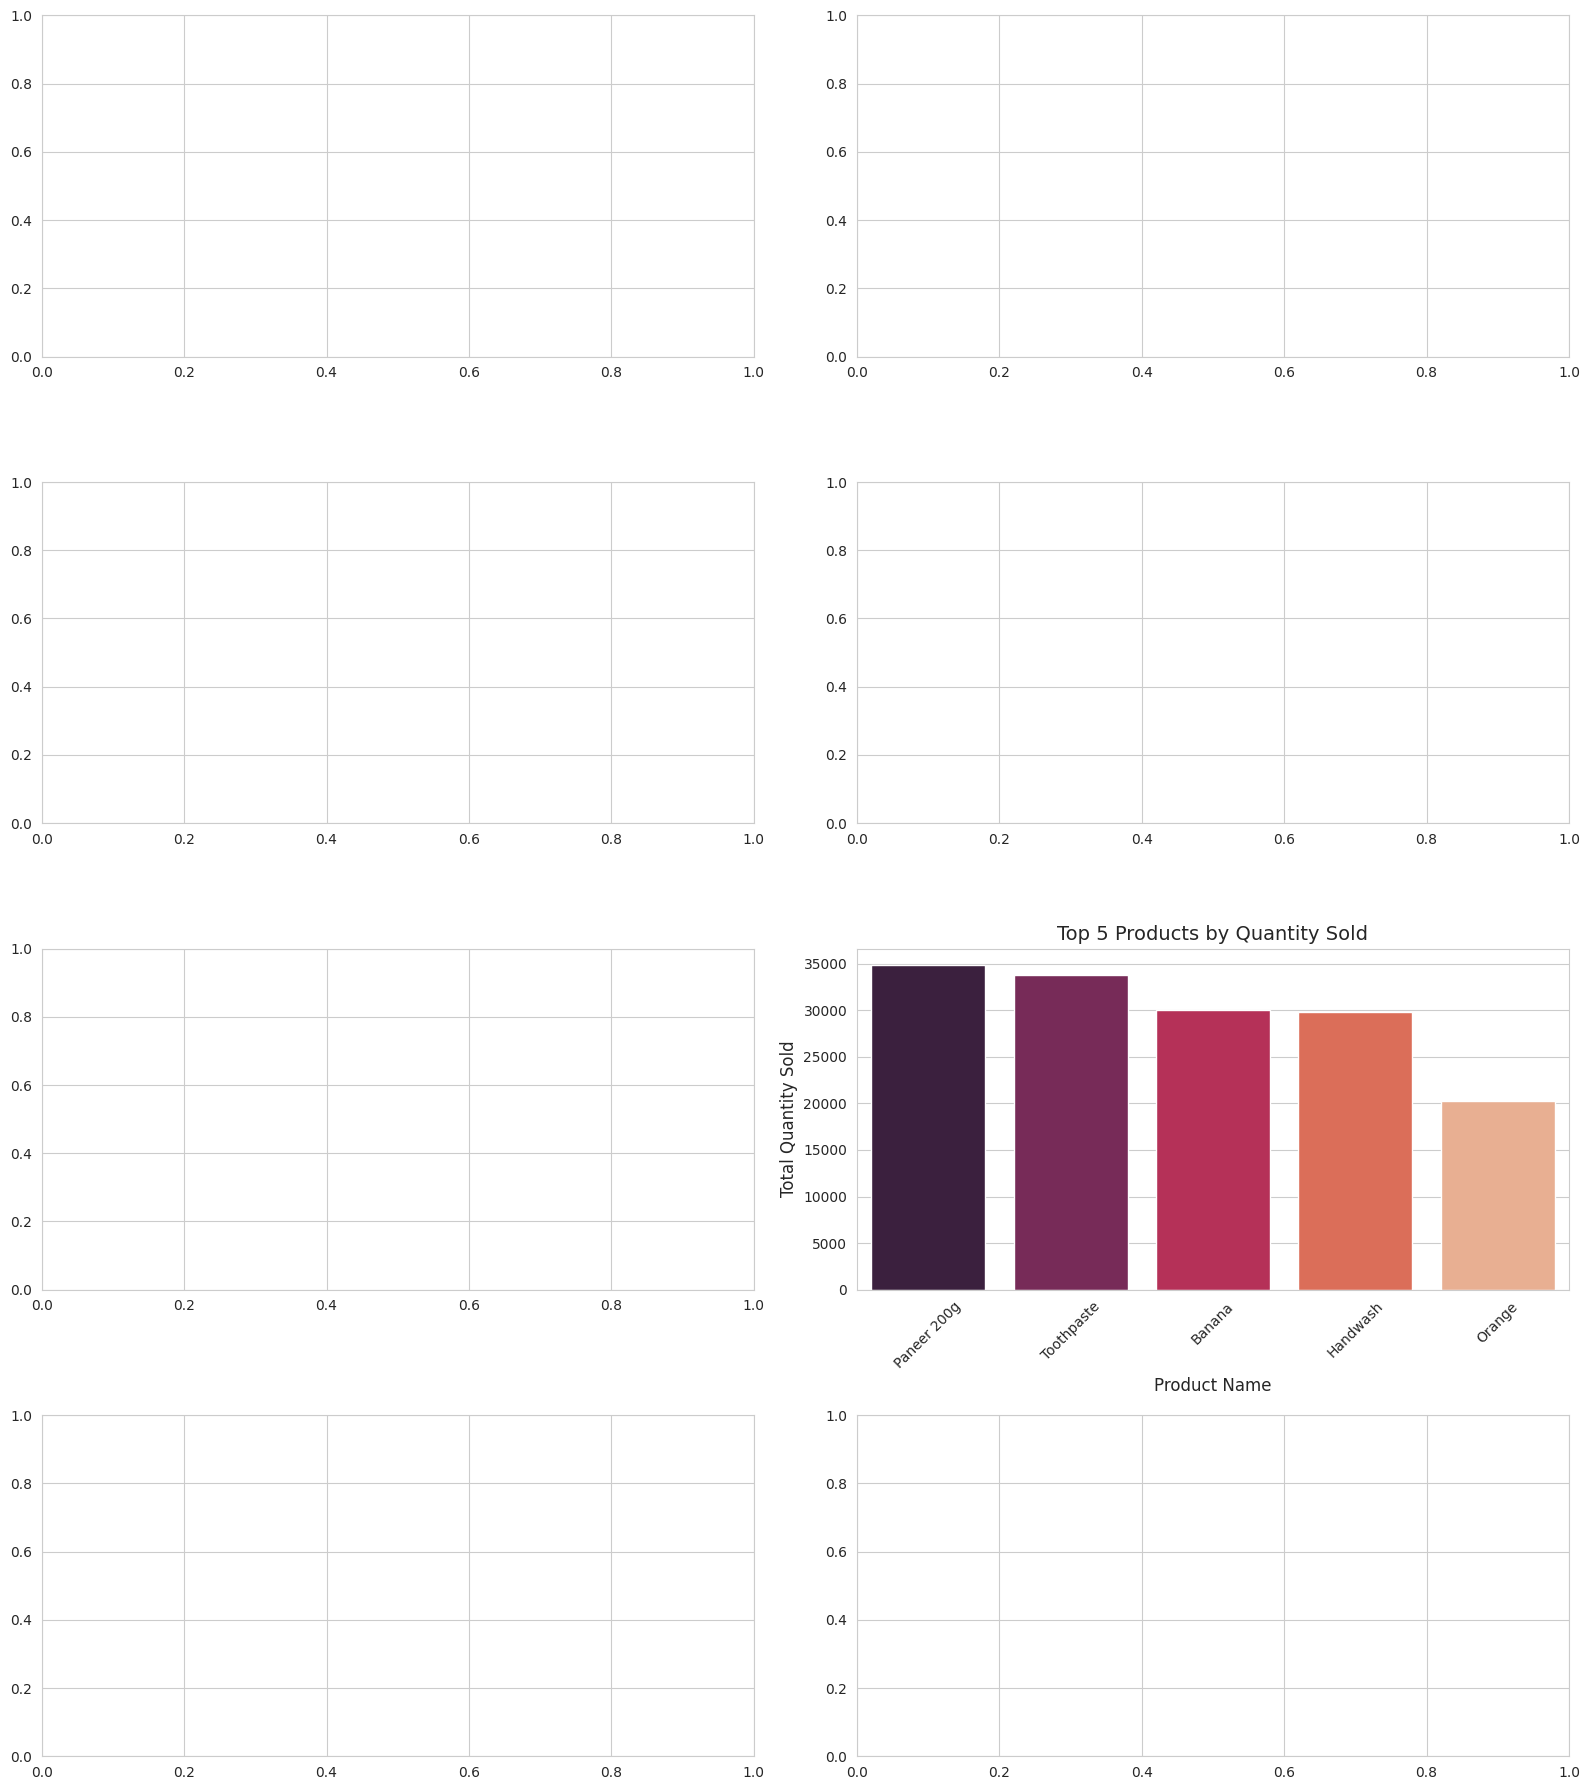

In [62]:
# Create subplot figure for 8 plots
fig, axes = plt.subplots(4, 2, figsize=(16,18))

# Top 5 products
top_products_qty = (
    df_sales.groupby('product_id')['quantity']
    .sum()
    .nlargest(5)
    .reset_index()
)

top_products_qty = top_products_qty.merge(
    df_products,
    on='product_id'
)

sns.barplot(
    x='product_name',
    y='quantity',
    hue='product_name',
    data=top_products_qty,
    palette='rocket',
    legend=False,
    ax=axes[2,1]
)

axes[2,1].set_title('Top 5 Products by Quantity Sold', fontsize=14)
axes[2,1].set_xlabel('Product Name', fontsize=12)
axes[2,1].set_ylabel('Total Quantity Sold', fontsize=12)
axes[2,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


# Plot 9: Sales by City and Month (Heatmap)

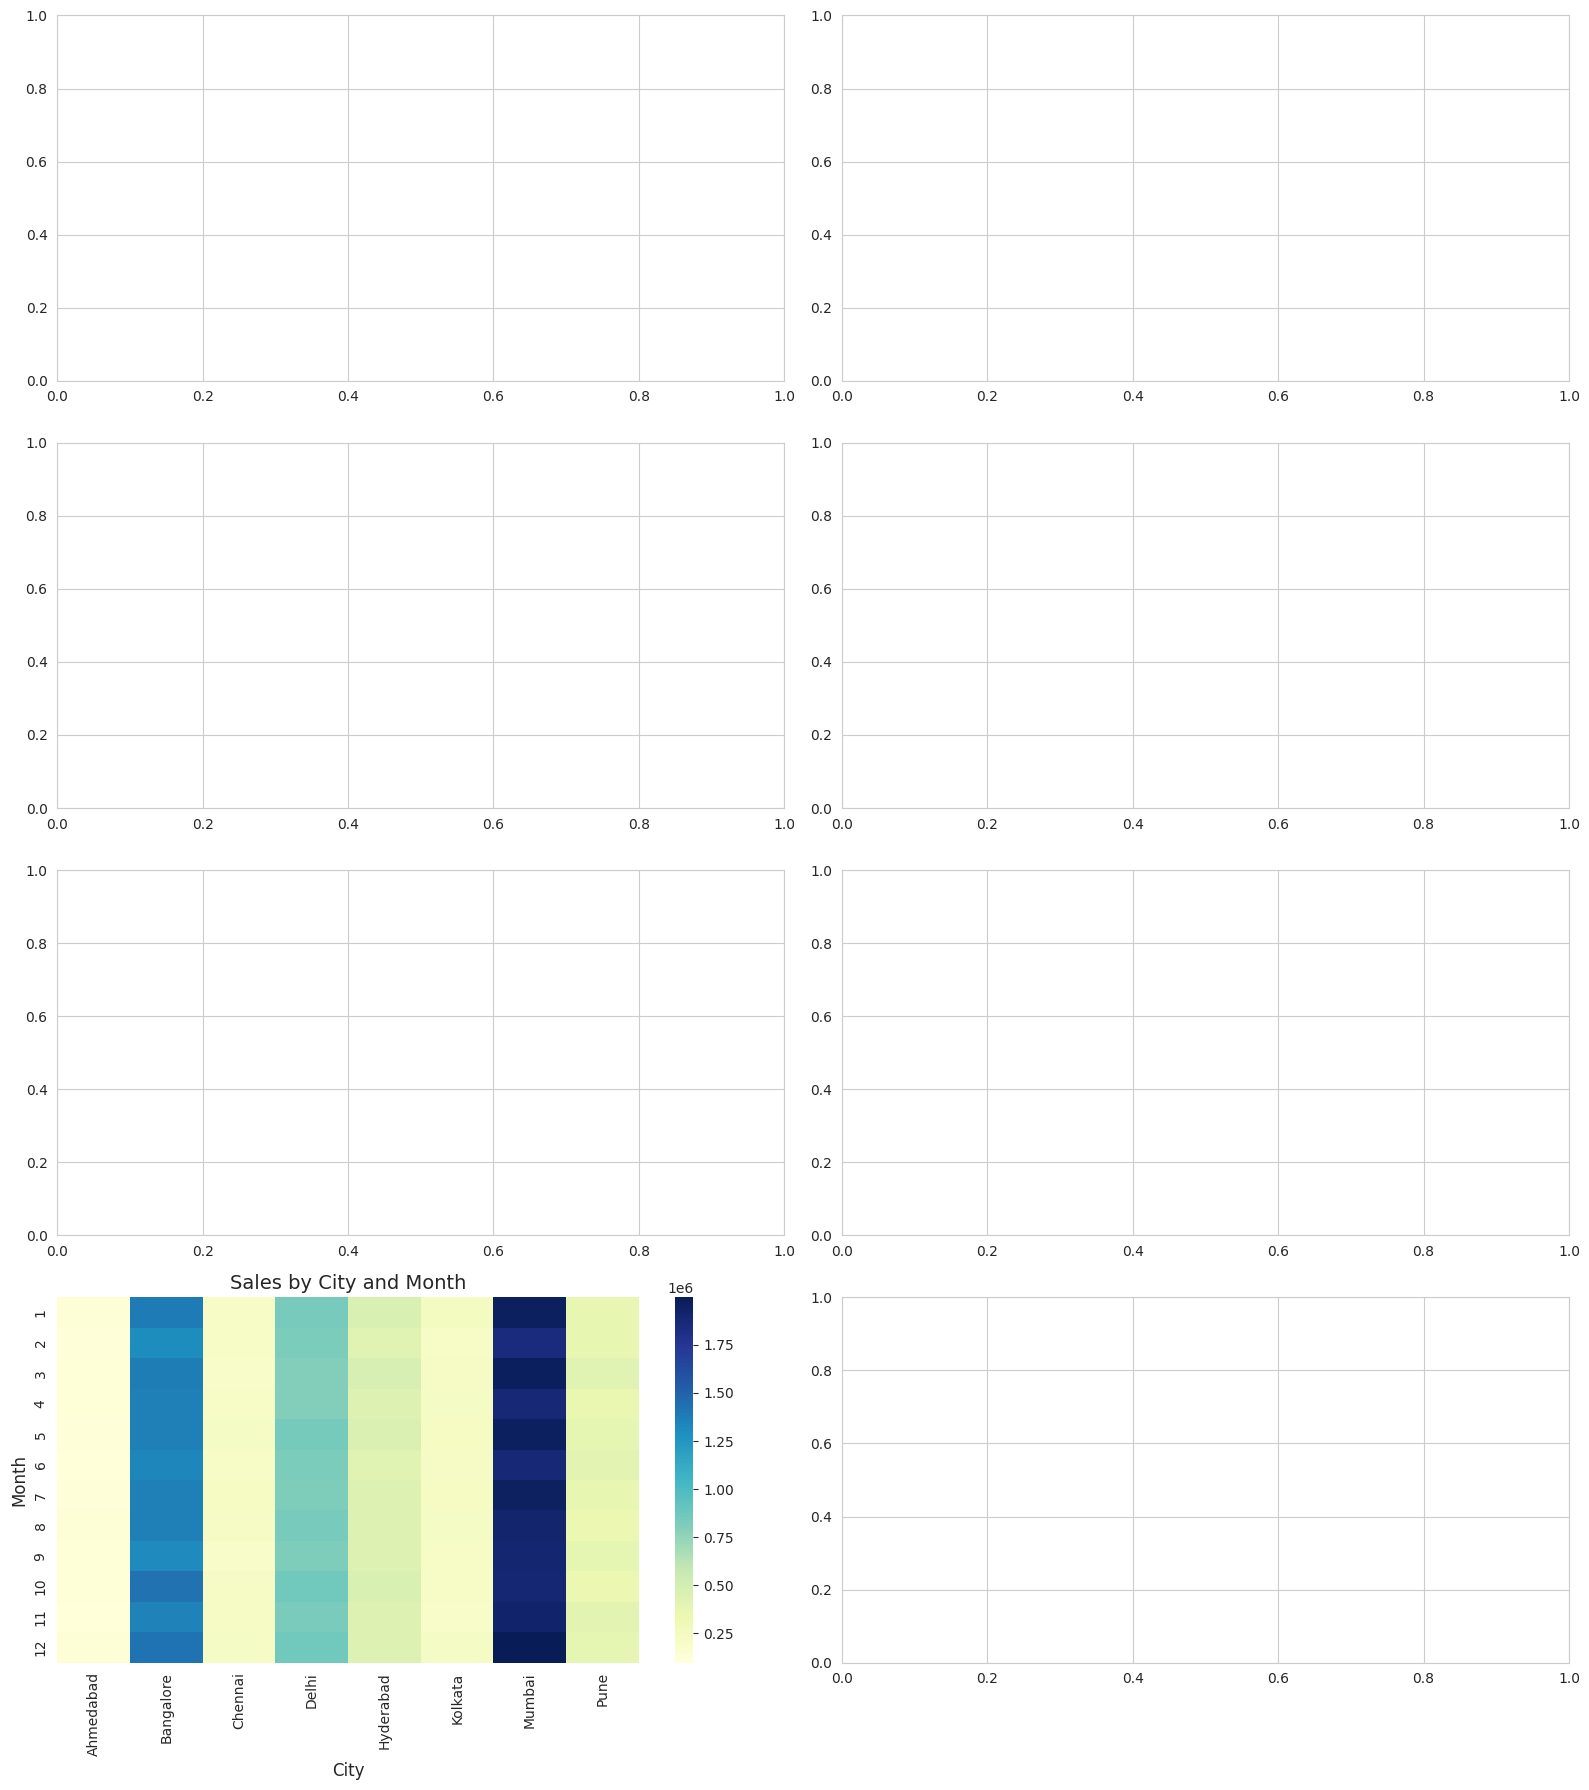

In [63]:
fig, axes = plt.subplots(4, 2, figsize=(16,18))

sales_city_month = df_sales.groupby(
    [df_sales['order_date'].dt.month, 'city']
)['total_amount'].sum().unstack(fill_value=0)

sns.heatmap(
    sales_city_month,
    cmap='YlGnBu',
    ax=axes[3,0]
)

axes[3,0].set_title('Sales by City and Month', fontsize=14)
axes[3,0].set_xlabel('City', fontsize=12)
axes[3,0].set_ylabel('Month', fontsize=12)

plt.tight_layout()
plt.show()